# 02_train_text2market_multilang — modifié

Notebook modifié pour :

- Charger les conférences (all_ECB_conferences.csv)
- Charger les prix (all_ECB_prices.csv : `timestamp,asset,price`)
- Calculer `price_direction` (+1 / -1)
- Construire features TF-IDF + FinBERT scores
- Entraîner un LogisticRegression
- Simuler un PnL cumulatif

Remplacez les chemins si besoin et exécutez cellule par cellule.


In [27]:
# Imports principaux
import os
import json
import hashlib
import sqlite3
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack

# plotting
import matplotlib.pyplot as plt

# Optional: transformers (utilisé pour scoring FinBERT) - import dans une cellule séparée


In [28]:
# --- Réglage threads (copié depuis ton fichier) ---
try:
    import torch
    torch.set_num_threads(max(1, os.cpu_count() // 2))
except Exception:
    pass

# Constantes
BATCH = 16
CSV_PATH = "all_ECB_conferences.csv"  # <-- adapte si besoin
PRICES_CSV = "prices.csv"     # fichier prix fourni


In [29]:
# --- Lecture des conférences / nettoyage texte ---
df_raw = pd.read_csv(CSV_PATH)
# Assure-toi que df_raw contient au moins : date, title, link, text
print("Conferences loaded:", df_raw.shape)
df_raw["text"] = df_raw["text"].fillna("").astype(str).str.replace("\r\n", "\n")
df_raw.head(3)


Conferences loaded: (326, 4)


,date,title,link,text
0,1998-06-09,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea..."
1,1998-07-08,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea..."
2,1998-09-11,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea..."


In [30]:
# --- Detect languages ---
# As recall : for English MDL_EN = "ProsusAI/finbert" and for other languages "cardiffnlp/twitter-xlm-roberta-base-sentiment"

try:
    from langdetect import detect
except ImportError:
    raise ImportError("Install 'langdetect' :  pip install langdetect")

def _detect_lang(txt):
    try:
        return detect(txt)
    except Exception:
        return "unknown"

# "unknown" if no text
tqdm.pandas(desc="langdetect")
df_raw["lang"] = df_raw["text"].progress_apply(lambda t: _detect_lang(t) if t.strip() else "unknown")
# Normalize : if not in english 'en'
df_raw["lang"] = df_raw["lang"].apply(lambda x: "en" if x=="en" else "other")
df_raw[["date","lang"]].head()


langdetect:   0%|          | 0/326 [00:00<?, ?it/s]

,date,lang
0,1998-06-09,en
1,1998-07-08,en
2,1998-09-11,en
3,1998-10-13,en
4,1998-11-03,en


In [31]:
# --- MODEL for sentiment (FinBERT / multilingual) ---
# Défauts — adapte si tu utilises d'autres checkpoints
MDL_EN = globals().get("MDL_EN", "ProsusAI/finbert")
MDL_ML = globals().get("MDL_ML", "cardiffnlp/twitter-xlm-roberta-base-sentiment")

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
except Exception as e:
    print("Transforms not installed. To use FinBERT scoring install: pip install transformers torch")
    raise

DEV = 0 if torch.cuda.is_available() else -1  

tok_en = AutoTokenizer.from_pretrained(MDL_EN)
mod_en = AutoModelForSequenceClassification.from_pretrained(MDL_EN)
pipe_en = TextClassificationPipeline(model=mod_en, tokenizer=tok_en, device=DEV)

tok_ml = AutoTokenizer.from_pretrained(MDL_ML)
mod_ml = AutoModelForSequenceClassification.from_pretrained(MDL_ML)
pipe_ml = TextClassificationPipeline(model=mod_ml, tokenizer=tok_ml, device=DEV)

# Finbert : Max length 512
MAX_LEN_EN = getattr(tok_en, "model_max_length", 512)
if MAX_LEN_EN is None or MAX_LEN_EN > 100000:
    MAX_LEN_EN = 512

# XLM-R / RoBERTa : Max length 514
MAX_LEN_ML = getattr(tok_ml, "model_max_length", 514)
if MAX_LEN_ML is None or MAX_LEN_ML > 100000:
    MAX_LEN_ML = 514


Device set to use cpu
Device set to use cpu


In [32]:
# --- Cache SQLite for sentiment results ---
CACHE_DB = "sent_cache.sqlite"
con = sqlite3.connect(CACHE_DB)
con.execute("CREATE TABLE IF NOT EXISTS cache (k TEXT PRIMARY KEY, v TEXT NOT NULL)")
con.commit()

def _key(model_name, txt):
    return hashlib.sha1((model_name+"||"+txt).encode("utf-8")).hexdigest()

def _scores_from_predlist(pred_list):
    d = {x["label"].lower(): float(x["score"]) for x in pred_list}
    if "label_0" in d or "label 0" in d:
        neg = d.get("label_0", d.get("label 0", 0.0))
        neu = d.get("label_1", d.get("label 1", 0.0))
        pos = d.get("label_2", d.get("label 2", 0.0))
    else:
        pos = d.get("positive", d.get("pos", 0.0))
        neu = d.get("neutral",  d.get("neu", 0.0))
        neg = d.get("negative", d.get("neg", 0.0))
    return {"pos": pos, "neu": neu, "neg": neg, "polarity": pos - neg}

def _cache_get(keys):
    if not keys:
        return {}
    q = ",".join(["?"]*len(keys))
    cur = con.execute(f"SELECT k,v FROM cache WHERE k IN ({q})", keys)
    return dict(cur.fetchall())

def _cache_set(mapping):
    if not mapping:
        return
    con.executemany("INSERT OR REPLACE INTO cache(k,v) VALUES (?,?)",
                    list(mapping.items()))
    con.commit()


In [33]:
# --- Scoring multi-langues (utilise pipe_en et pipe_ml) ---
def score_multilang_from_df(df_texts, batch=BATCH):
    texts = df_texts["text"].fillna("").astype(str).tolist()
    langs = df_texts["lang"].tolist()
    out = [None]*len(texts)

    keys_en = [_key(MDL_EN, t) for t,l in zip(texts, langs) if l == "en"]
    keys_ml = [_key(MDL_ML, t) for t,l in zip(texts, langs) if l != "en"]
    cached = _cache_get(keys_en + keys_ml)
    new_entries = {}

    for i,(t,l) in enumerate(zip(texts, langs)):
        k = _key(MDL_EN, t) if l == "en" else _key(MDL_ML, t)
        if k in cached:
            out[i] = json.loads(cached[k])

    def _process_idxs(idxs, pipe, model_name, max_len):
        for start in tqdm(range(0, len(idxs), batch), desc=model_name):
            sub = idxs[start:start+batch]
            preds = pipe(
                [texts[j] for j in sub],
                top_k=None,             # remplace return_all_scores
                truncation=True,
                padding=True,
                max_length=max_len,
                batch_size=min(batch, len(sub)),
                return_token_type_ids=False  
            )
            for j,p in zip(sub, preds):
                sc = _scores_from_predlist(p)
                out[j] = sc
                new_entries[_key(model_name, texts[j])] = json.dumps(sc)

    idx_en = [i for i,(t,l) in enumerate(zip(texts, langs))
              if l == "en" and _key(MDL_EN, t) not in cached]
    idx_ml = [i for i,(t,l) in enumerate(zip(texts, langs))
              if l != "en" and _key(MDL_ML, t) not in cached]

    if idx_en: _process_idxs(idx_en, pipe_en, MDL_EN, MAX_LEN_EN)
    if idx_ml: _process_idxs(idx_ml, pipe_ml, MDL_ML, MAX_LEN_ML)

    _cache_set(new_entries)
    return pd.DataFrame(out)


In [34]:
# --- Apply sentiment scoring to conferences ---
sent_df = score_multilang_from_df(df_raw, batch=BATCH)

df_scored = pd.concat([df_raw.reset_index(drop=True),
                       sent_df.reset_index(drop=True)], axis=1)
df_scored.head()


,date,title,link,text,lang,pos,neu,neg,polarity
0,1998-06-09,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea...",en,0.032779,0.942236,0.024984,0.007795
1,1998-07-08,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea...",en,0.733954,0.170740,0.095306,0.638648
2,1998-09-11,Willem F. Duisenberg: ECB Press conference: In...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea...",en,0.050362,0.728460,0.221179,-0.170817
3,1998-10-13,Willem F. Duisenberg: Introductory statement w...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea...",en,0.139786,0.747997,0.112217,0.027569
4,1998-11-03,Willem F. Duisenberg: Introductory statement w...,https://www.ecb.europa.eu/press/press_conferen...,"Willem F. Duisenberg, President of the Europea...",en,0.028792,0.062427,0.908781,-0.879990


In [35]:
# --- LOAD PRICES and prepare price series ---
# Expecting columns: timestamp, asset, price
prices = pd.read_csv(PRICES_CSV)
print("Prices loaded:", prices.shape)
prices['timestamp'] = pd.to_datetime(prices['timestamp'])
# If there are multiple assets, we take the last available price per timestamp
# (You can filter by asset if needed: prices = prices[prices['asset']=="YOUR_ASSET"])
# Aggregate to daily last price to match conference dates (if conference dates are date only)
prices = prices.sort_values("timestamp").groupby("timestamp", as_index=False).last()

# Make sure conference dates are datetime
df_scored['date'] = pd.to_datetime(df_scored['date'])

# If conference times are full timestamps, we'll merge_asof on timestamps.
# Otherwise, if conferences have only dates, convert timestamps to dates.
# Here we try to merge on timestamp if possible; otherwise fallback to date-only merging.

# First attempt: merge_asof on timestamp (nearest previous price)
try:
    # if df_scored has time component:
    df_scored = df_scored.sort_values("date")
    prices = prices.sort_values("timestamp")
    merged = pd.merge_asof(df_scored, prices, left_on="date", right_on="timestamp", direction="backward")
except Exception as e:
    # fallback: align by date only
    print("merge_asof failed, falling back to date-only merge:", e)
    prices['date'] = prices['timestamp'].dt.date
    df_scored['date_only'] = df_scored['date'].dt.date
    prices_daily = prices.sort_values("date").groupby("date", as_index=False).last()
    merged = pd.merge(df_scored, prices_daily, left_on="date_only", right_on="date", how="left")

# The merged DataFrame should now contain a 'price' column
print("Merged shape:", merged.shape)
merged[['date','timestamp','price']].tail()


Prices loaded: (14753, 3)
Merged shape: (326, 12)


,date,timestamp,price
321,2025-07-24,2025-07-24,54.549999
322,2025-07-24,2025-07-24,54.549999
323,2025-09-11,2025-09-11,54.959999
324,2025-09-11,2025-09-11,54.959999
325,2025-10-30,2025-10-30,31.094999


In [ ]:
# --- CALCULATE price change and direction ---
# Sort by timestamp to compute diff
merged = merged.sort_values("timestamp").reset_index(drop=True)

# If multiple price entries are missing, forward/backfill may be useful
merged['price'] = merged['price'].ffill().bfill()

# Compute price change compared to previous price (previous row)
merged['price_change'] = merged['price'].diff()

# Create price_direction: +1 if price increased vs previous, else -1
merged['price_direction'] = merged['price_change'].apply(lambda x: 1 if x > 0 else 0)

merged[['timestamp','price','price_change','price_direction']].head(10)


SyntaxError: invalid syntax (1324290344.py, line 12)

In [ ]:
# --- FEATURES : TF-IDF (text) + FinBERT scores (pos,neu,neg,polarity) ---
# TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(merged['text'].fillna(""))

# Sentiment features (ensure numeric)
sent_cols = ['pos','neu','neg','polarity']
for c in sent_cols:
    if c not in merged.columns:
        merged[c] = 0.0
X_sent = merged[sent_cols].fillna(0).values

# Combine sparse TF-IDF with dense sentiment features
X = hstack([X_tfidf, X_sent])

# Target
y = merged['price_direction'].values

# Train/test split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, merged.index.values, test_size=0.2, random_state=42, stratify=None
)

# Train logistic regression
model = LogisticRegression(max_iter=500, class_weight='balanced')
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.5303030303030303
              precision    recall  f1-score   support

          -1       0.73      0.49      0.59        45
           1       0.36      0.62      0.46        21

    accuracy                           0.53        66
   macro avg       0.55      0.55      0.52        66
weighted avg       0.61      0.53      0.55        66

Confusion matrix:
 [[22 23]
 [ 8 13]]


In [ ]:
# --- Train/test split & XGBoost
%pip install xgboost
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, merged.index.values, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",   # plus rapide sur gros dataset
    use_label_encoder=False
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\\n", confusion_matrix(y_test, y_pred))


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
    --------------------------------------- 1.3/72.0 MB 4.3 MB/s eta 0:00:17
   -- ------------------------------------- 3.9/72.0 MB 8.2 MB/s eta 0:00:09
   --- ------------------------------------ 5.8/72.0 MB 9.7 MB/s eta 0:00:07
   --- ------------------------------------ 6.3/72.0 MB 6.9 MB/s eta 0:00:10
   ---- ----------------------------------- 7.9/72.0 MB 6.9 MB/s eta 0:00:10
   ----- ---------------------------------- 10.2/72.0 MB 7.6 MB/s eta 0:00:09
   ----- ---------------------------------- 10.7/72.0 MB 7.9 MB/s eta 0:00:08
   ----- ---------------------------------- 10.7/72.0 MB 7.9 MB/s eta 0:00:08
   ------ --------------------------------- 11.5/72.0 MB 5.9 MB/s eta 0:00:11
   ------- -------------------------------- 13.4/72.0 MB 6.1 MB/s eta 0:00:10
   -------- ------------------------------- 15.7/72.0 MB 6.6 MB/s eta 0:00:09
   ----

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [-1  1]

Final cumulative PnL (full preds): 172.2257480621338
Final cumulative PnL (test preds): -77.07557618618011


C:\Users\Garance Latieule\AppData\Local\Temp\ipykernel_74972\3758054686.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['pred_test'] = merged['pred_test'].fillna(method='ffill')  # just to avoid NaN display


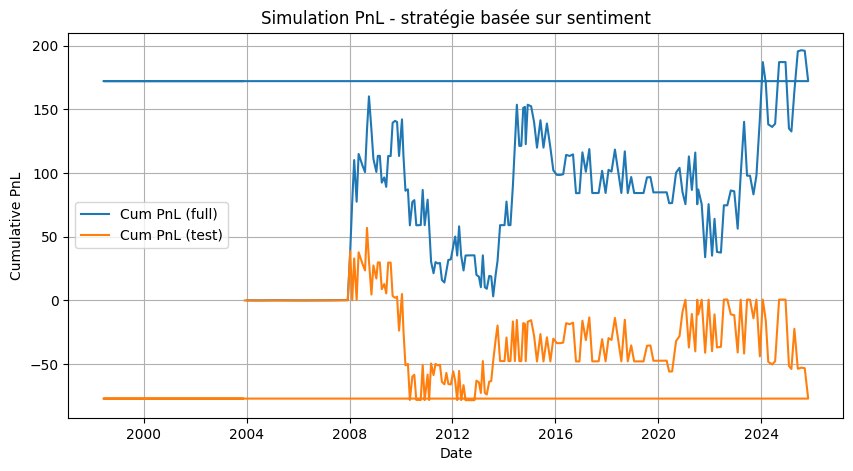

In [ ]:
# --- PnL simulation over the full dataset (in-sample predictions) ---
# You may prefer to simulate only on test set; here we show both options.

# Full-sample predictions
merged['pred_full'] = model.predict(X)

# PnL per row: if pred==1 (long) gain = price_change, else short => gain = -price_change
merged['pnl_trade'] = merged.apply(lambda r: r['price_change'] if r['pred_full']==1 else -r['price_change'], axis=1)
merged['cum_pnl'] = merged['pnl_trade'].cumsum()

# Test-set PnL (using model trained above)
# Build predictions for test indices
# Note: we have idx_test from train_test_split
merged.loc[idx_test, 'pred_test'] = model.predict(X_test)
merged['pred_test'] = merged['pred_test'].fillna(method='ffill')  # just to avoid NaN display
# PnL based on test predictions (only meaningful for rows in idx_test)
merged['pnl_test'] = merged.apply(lambda r: r['price_change'] if r.get('pred_test', np.nan)==1 else (-r['price_change'] if r.get('pred_test', np.nan)==-1 else 0.0), axis=1)
merged['cum_pnl_test'] = merged['pnl_test'].cumsum()

print("Final cumulative PnL (full preds):", merged['cum_pnl'].iloc[-1])
print("Final cumulative PnL (test preds):", merged['cum_pnl_test'].iloc[-1])

# Plot PnL
plt.figure(figsize=(10,5))
plt.plot(merged['date'], merged['cum_pnl'], label='Cum PnL (full)')
plt.plot(merged['date'], merged['cum_pnl_test'], label='Cum PnL (test)')
plt.legend()
plt.title("Simulation PnL - stratégie basée sur sentiment")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.show()


In [ ]:
# --- OPTIONNEL : sauvegarder le modèle et le vecteur TF-IDF ---
import joblib
joblib.dump(model, "sentiment_price_logreg.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
print("Saved model and TF-IDF vectorizer.")


Saved model and TF-IDF vectorizer.


## Notes / remarques

"
- Le notebook suppose que `all_ECB_prices.csv` contient `timestamp,asset,price`. Si tu veux filtrer un `asset` particulier, ajoute `prices = prices[prices['asset']=='TON_ASSET']` avant l'agrégation.

"
- La stratégie de PnL ci-dessus est simplifiée : pas de frais, pas de slippage, tailles fixes par trade. Adapte selon ta réalité.

"
- Pour un workflow plus robuste :
"
  - Faire un backtest sur périodes hors-échantillon (rolling window),
"
  - Ajouter features temporelles, lagged returns, et normalisation,
"
  - Tester d'autres classifieurs (RandomForest, XGBoost) et calibration des probabilités.

"
Bonne exécution — tu peux télécharger le notebook via le lien renvoyé ci-dessous.
